# GAMPixPy Simulation Example

This notebook is meant to show you the most basic workflow for processing a single event with the GAMPixPy framework.  It follows a very similar script which you can find in `examples/gampix_sim.py`

First, import some necessary modules from the gampixpy library:

In [1]:
from gampixpy import detector, input_parsing, plotting, config, output

Next, some related libraries which are needed for this notebook:

In [2]:
# set up matplotlib for this notebook
%matplotlib widget

# import torch and set the default device (needed for GPU)
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    # Set the default device to CUDA
    torch.set_default_device(device)
    print(f"Default device set to: {torch.cuda.get_device_name(device)}")
else:
    device = torch.device('cpu')
    print("CUDA is not available, using CPU")

Default device set to: NVIDIA A100-SXM4-40GB


## Configuration

The first step in simulation is to define our detector and how it will behave.  These configuration parameters are divided into three categories:

- *detector config*: defines the physical size and location of the detector volume(s).
- *physics config*: defines the physical properties of the detector material (LAr) and parameters pertaining to drift mechanics and charge yield.  These parameters very rarely need to be changed, and the default is usually fine.
- *readout config*: defines the details of the anode plane e.g., pitches for coarse tiles and pixels, noise levels, thresholds, etc.

These config objects act like dictionaries.  They will be used at various points by the library, so keep them handy!

After defining these, we'll use them to create a detector model.

In [3]:
detector_config = config.preset_detector_configs['far_detector_vd']
physics_config = config.default_physics_params
readout_config = config.preset_readout_configs['demo_large_pixels']

## We can also build one of these from a yaml file
## The configs which come along with the library are
## accessible from the `preset_[...]_configs`, but can
## also be found alongside the library code
# readout_config = config.ReadoutConfig('../../gampixpy/readout_config/GAMPixD_notruth.yaml')

detector_model = detector.DetectorModel(detector_params=detector_config,
                                        physics_params=physics_config,
                                        readout_params=readout_config,
                                       )

## Input Parsing
Next, we need to read some events from a file on disk.  Included with this library are a few example inputs.  We'll read some edep-sim output which has been dumped to HDF5 format, but we can also read directly from a ROOT file in the ROOTracker format

In [4]:
input_file = '../inputs/muon_1-4GeV.h5'
input_parser = input_parsing.EdepSimParser(input_file,
                                           readout_config=readout_config)

# Get a single event from this input file
event_index = 3
event_data = input_parser.get_sample(event_index)
event_meta = input_parser.get_meta(event_index)

## Simulation

Once we have configured our detector model and read in some input data, simulation is easy!

In [5]:
detector_model.drift(event_data)
detector_model.readout(event_data)

## This can also be done as a single step
# detector_model.simulate(event_data)

simulating coarse grid...
coarse time series built
coarse hit finding...
simulating fine grid...
pixel time series built
pixel hit finding...
found 8 coarse tile hits
found 1900 pixel hits


## Visualization
Now, let's take a look at the results of the simulation:

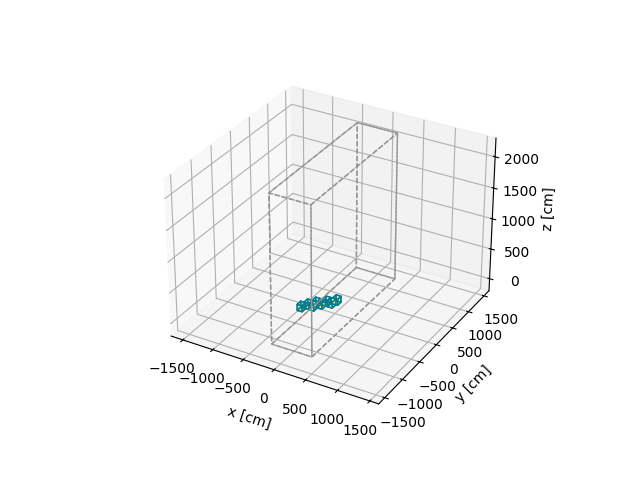

In [6]:
evd = plotting.EventDisplay(event_data)

#evd.plot_raw_track()

evd.plot_drift_volumes(detector_config)

evd.plot_coarse_tile_measurement(readout_config,
                                 physics_config,
                                 detector_config,
                                ) # plot tile hits

evd.plot_pixel_measurement(readout_config,
                               physics_config,
                              detector_config,
                              ) # plot pixel hits

evd.show()

## File Output
To record the simulation outputs, we use the included output management system

In [7]:
!rm test_output.h5
om = output.OutputManager('test_output.h5')
om.add_entry(event_data, event_meta)